In [17]:
from dotenv import load_dotenv
load_dotenv()

True

In [18]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import InMemoryVectorStore
from langchain_google_genai import ChatGoogleGenerativeAI

from langgraph.graph import StateGraph,START,END
from pydantic import BaseModel,Field

In [19]:
##Document Loaders

loader=PyPDFLoader("../data/medical_report.pdf")
docs=loader.load()

##Document splitter
splitter=RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=200)
docs=splitter.split_documents(docs)

##embeddings and vector db
embeddings=GoogleGenerativeAIEmbeddings(model="gemini-embedding-001")
vector_db=InMemoryVectorStore.from_documents(
    documents=docs,
    embedding=embeddings
)

In [ ]:
class RagState(BaseModel):
    question:str=Field(description="User Question")
    documents:list=[]  
    context:str=Field(description="Context data for User Question",default="")
    answer:str=Field(description="Final Answer",default="")
    

In [21]:
llm=ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

In [51]:
##question->retriveve->context->generate->end

def retriveve_node(state:RagState)->RagState:
    docs=vector_db.similarity_search(query=state.question)
    state.documents=docs
    return state

def create_context_node(state:RagState)->RagState:
    context=""
    for doc in state.documents:
        context+=doc.page_content+"\n\n"
    state.context=context
    return state

def generate_node(state:RagState)->RagState:
    prompt=f"""
        You are a assistent and provide the answer for user question based on the provided context.If you don't find the relevent answer,then just say "I don't know"
        context is :{state.context}
        question is :{state.question}
    """
    res=llm.invoke(prompt)
    state.answer=res.content[0]["text"]
    return state



In [52]:
graph=StateGraph(RagState)

graph.add_node("Retrieve",retriveve_node)
graph.add_node("context",create_context_node)
graph.add_node("generate",generate_node)

graph.add_edge(START,"Retrieve")
graph.add_edge("Retrieve","context")
graph.add_edge("context","generate")
graph.add_edge("generate",END)

graph=graph.compile()





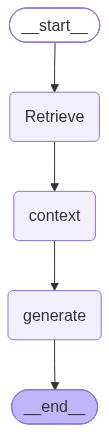

In [40]:
graph

In [53]:
res=graph.invoke({"question":"What is the name of the patient"})

In [56]:
res["answer"]

'Based on the provided context, the name of the patient is Ms. NIKITA CHUDHARY.'